In [18]:
# ============================================================
# Big Data Analytics - Homework 1
# Energy Sector Analysis
# ============================================================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# Formatting utilities
from matplotlib.ticker import FuncFormatter

# Plot style
plt.style.use('ggplot')

# Formatter for large values in billions
def billions_formatter(x, pos):
    return f'{x/1e9:.0f}B'

print("Setup completed successfully.")

Setup completed successfully.


In [35]:
# ============================================================
# Step 0 — Dataset Loading
# ============================================================

# Load the dataset containing company financial information
df = pd.read_csv("data/symbol_info_3-25.csv")

# Display dataset dimensions
print("Dataset shape:", df.shape)

# Preview first rows
df.head()

Dataset shape: (1000, 38)


,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,...,payout_ratio,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp
0,AAPL,Apple Inc.,Technology,Consumer Electronics,3278873821184,3321891913728,218.270004,214.100006,260.100006,164.080002,...,0.1571,52181373,2.71,NMS,NMS,United States,0,0,1,2025-03-22 04:50:05
1,MSFT,Microsoft Corporation,Technology,Software - Infrastructure,2908619014144,2939973795840,391.260010,386.839996,468.350006,376.910004,...,0.2482,22370941,2.68,NMS,NMS,United States,0,0,1,2025-03-22 04:50:07
2,NVDA,NVIDIA Corporation,Technology,Semiconductors,2892136185856,2838940090368,117.699997,118.529999,153.130005,75.606003,...,0.0116,271988186,0.84,NMS,NMS,United States,0,0,1,2025-03-22 04:50:06
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,Internet Retail,2079374704640,2133579530240,196.210007,194.949997,242.520004,151.610001,...,0.0000,38226331,1.78,NMS,NMS,United States,0,0,1,2025-03-22 04:50:08
4,GOOGL,Alphabet Inc.,Communication Services,Internet Content & Information,1996906430464,1931518148608,163.990005,162.800003,207.050003,147.220001,...,0.0746,29147868,2.01,NMS,NMS,United States,0,0,1,2025-03-22 04:50:09


In [51]:
# ============================================================
# Step 0 — Dataset Cleaning and Sector Filtering
# ============================================================

# Keep only actively trading companies
df = df[df['is_actively_trading'] == 1]

# Remove ETFs and funds from the analysis
df = df[(df['is_etf'] == 0) & (df['is_fund'] == 0)]

# Filter the dataset for the Energy sector
energy_df = df[df['sector'] == 'Energy']

# Display the dimensions of the filtered dataset
print("Energy sector dataset shape:", energy_df.shape)

Energy sector dataset shape: (54, 38)


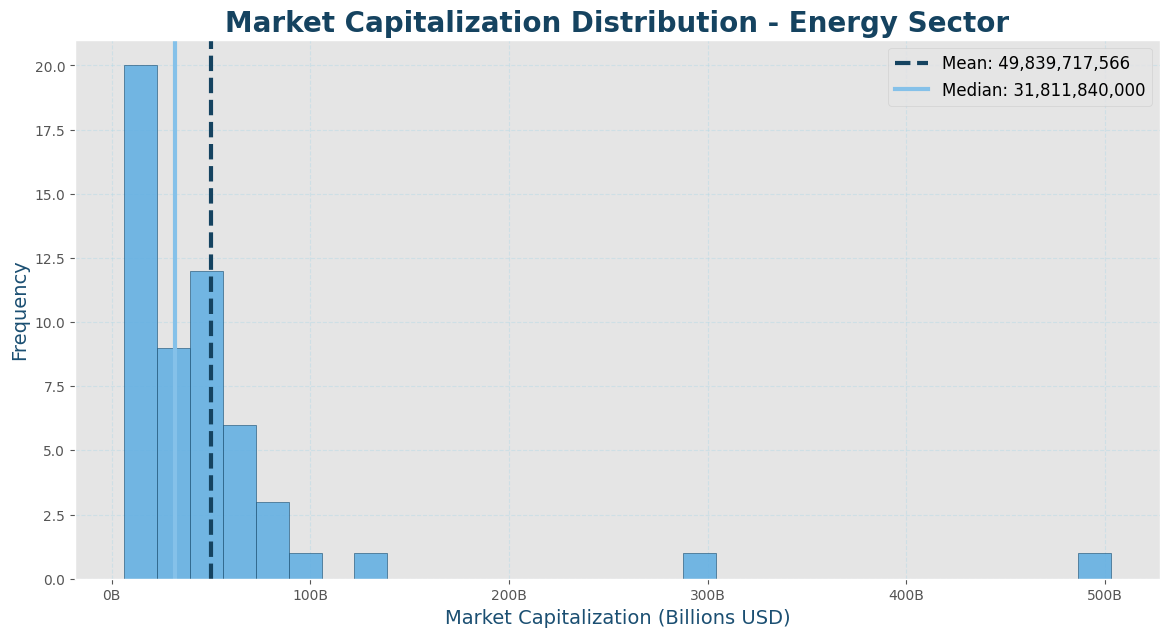

In [65]:
# ============================================================
# Step 1 — Market Capitalization Distribution
# ============================================================

# Calculate mean and median market capitalization
mean_cap = energy_df['market_cap'].mean()
median_cap = energy_df['market_cap'].median()

# Create figure
plt.figure(figsize=(14,7))

# Histogram of market capitalization
plt.hist(
    energy_df['market_cap'],
    bins=30,
    color='#5DADE2',
    edgecolor='#1B4F72',
    alpha=0.85
)

# Mean line
plt.axvline(
    mean_cap,
    color='#154360',
    linestyle='--',
    linewidth=3,
    label=f"Mean: {mean_cap:,.0f}"
)

# Median line
plt.axvline(
    median_cap,
    color='#85C1E9',
    linestyle='-',
    linewidth=3,
    label=f"Median: {median_cap:,.0f}"
)

# Improve readability using billions formatting
plt.gca().xaxis.set_major_formatter(FuncFormatter(billions_formatter))

# Grid styling
plt.grid(color='lightblue', linestyle='--', alpha=0.4)

# Titles and labels
plt.title(
    "Market Capitalization Distribution - Energy Sector",
    fontsize=20,
    fontweight='bold',
    color='#154360'
)

plt.xlabel(
    "Market Capitalization (Billions USD)",
    fontsize=14,
    color='#1B4F72'
)

plt.ylabel(
    "Frequency",
    fontsize=14,
    color='#1B4F72'
)

# Legend
plt.legend(fontsize=12)

plt.show()

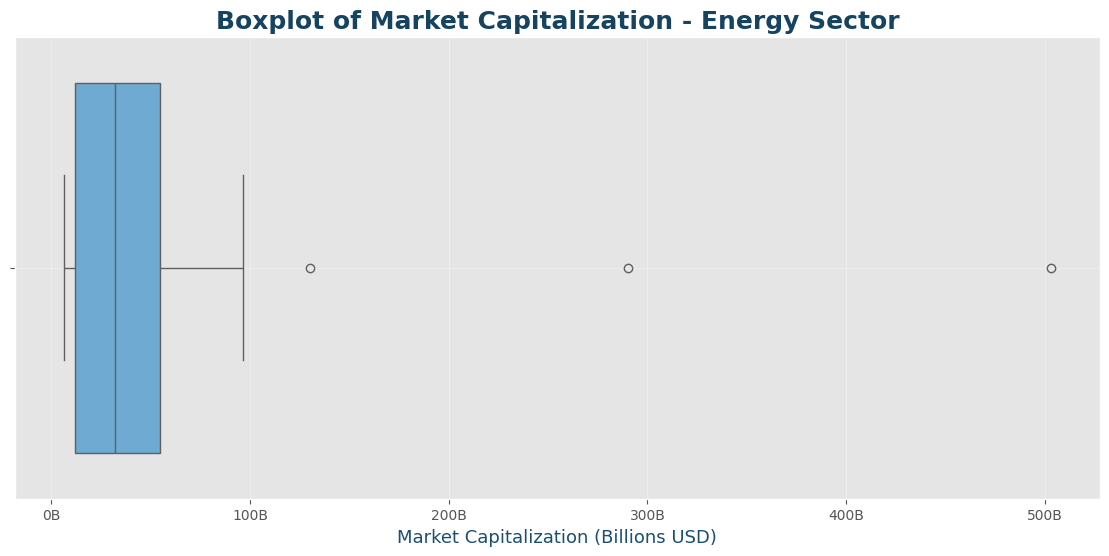

In [78]:
# ============================================================
# Step 2 — Outlier Detection
# ============================================================

# The boxplot helps identify extreme market capitalization
# values within the Energy sector.

plt.figure(figsize=(14,6))

sns.boxplot(
    x=energy_df['market_cap'],
    color='#5DADE2'
)

# Improve readability using billions formatting
plt.gca().xaxis.set_major_formatter(FuncFormatter(billions_formatter))

# Title
plt.title(
    "Boxplot of Market Capitalization - Energy Sector",
    fontsize=18,
    fontweight='bold',
    color='#154360'
)

# Label
plt.xlabel(
    "Market Capitalization (Billions USD)",
    fontsize=13,
    color='#1B4F72'
)

# Grid
plt.grid(alpha=0.3)

plt.show()

In [90]:
# ============================================================
# Step 2 — Outlier Removal
# ============================================================

# The IQR method is used to identify and remove
# extreme market capitalization outliers.

# Calculate quartiles
Q1 = energy_df['market_cap'].quantile(0.25)
Q3 = energy_df['market_cap'].quantile(0.75)

# Compute Interquartile Range
IQR = Q3 - Q1

# Define lower and upper thresholds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
energy_clean = energy_df[
    (energy_df['market_cap'] >= lower_bound) &
    (energy_df['market_cap'] <= upper_bound)
]

# Compare dataset dimensions before and after cleaning
print("Original dataset shape:", energy_df.shape)
print("Cleaned dataset shape:", energy_clean.shape)

Original dataset shape: (54, 38)
Cleaned dataset shape: (51, 38)


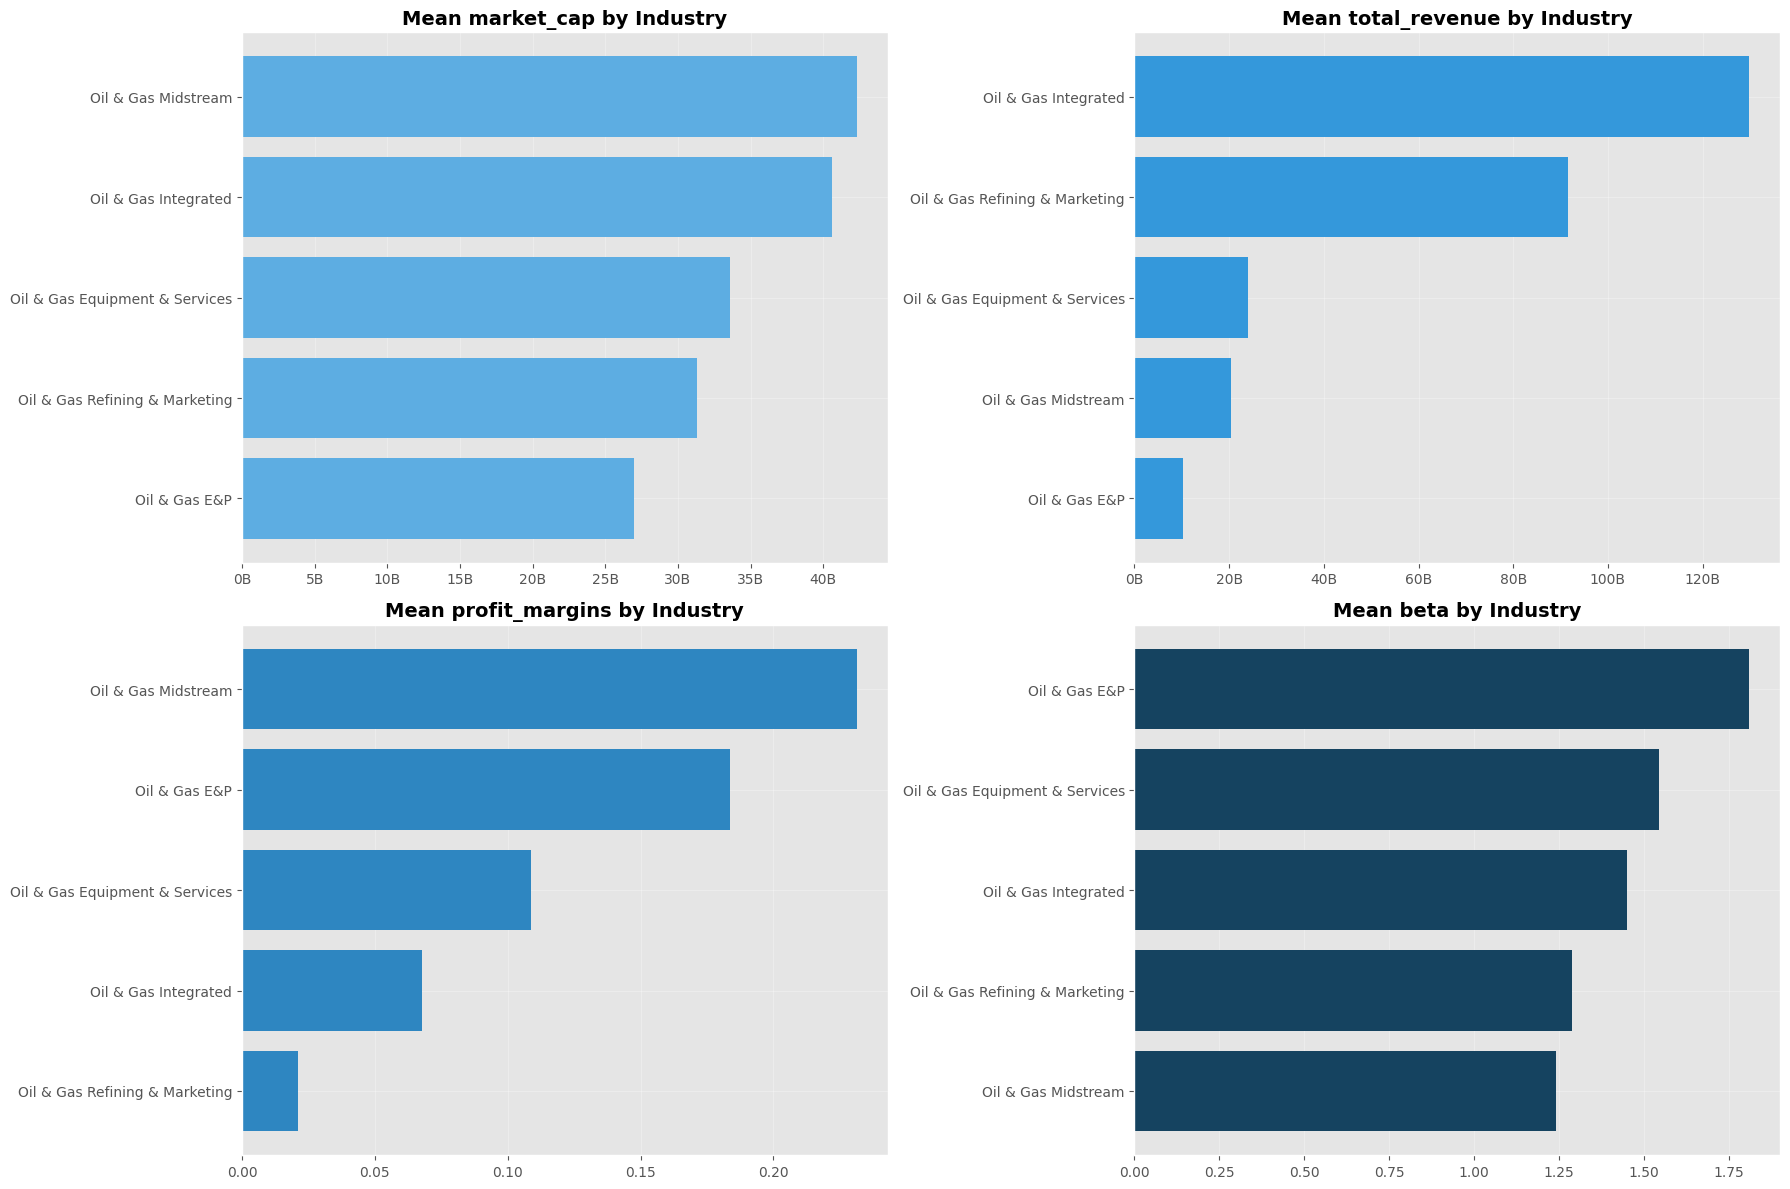

In [101]:
# ============================================================
# Step 3 — Industry Comparison
# ============================================================

# The following charts compare the average values
# of key financial metrics across Energy industries.

# Metrics to analyze
metrics = ['market_cap', 'total_revenue', 'profit_margins', 'beta']

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Flatten subplot array
axes = axes.flatten()

# Blue palette
colors = ['#5DADE2', '#3498DB', '#2E86C1', '#154360']

# Loop through metrics
for i, metric in enumerate(metrics):

    # Compute mean values by industry
    industry_mean = (
        energy_clean
        .groupby('industry')[metric]
        .mean()
        .sort_values()
    )

    # Horizontal bar chart
    axes[i].barh(
        industry_mean.index,
        industry_mean.values,
        color=colors[i]
    )

    # Improve readability for large values
    if metric in ['market_cap', 'total_revenue']:
        axes[i].xaxis.set_major_formatter(
            FuncFormatter(billions_formatter)
        )

    # Title
    axes[i].set_title(
        f'Mean {metric} by Industry',
        fontsize=14,
        fontweight='bold'
    )

    # Grid
    axes[i].grid(alpha=0.3)

# Improve spacing
plt.tight_layout()

plt.show()

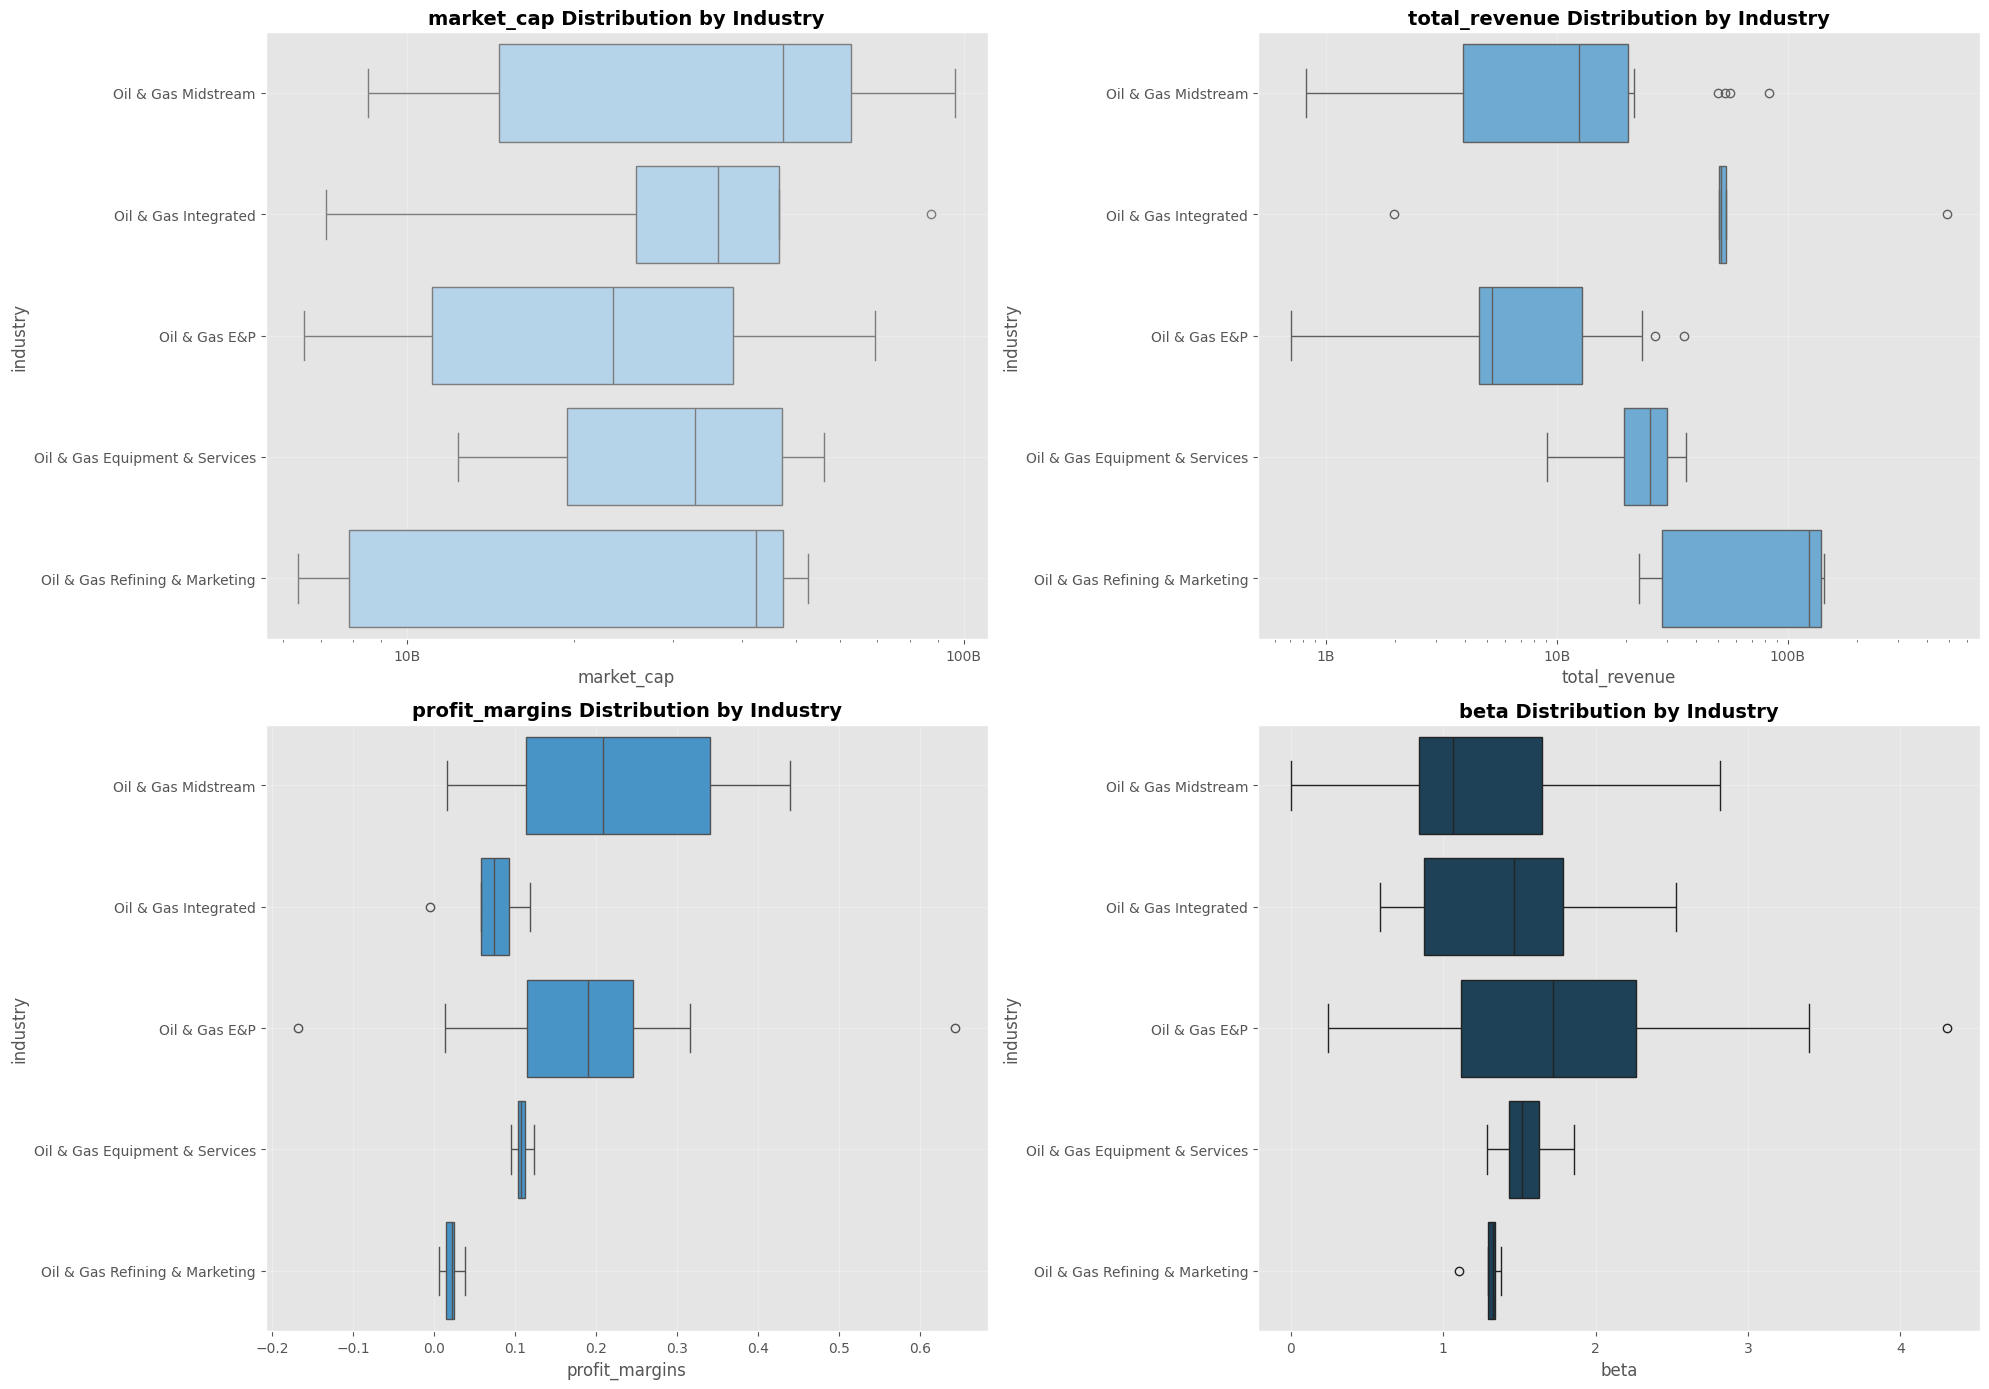

In [111]:
# ============================================================
# Step 4 — Industry Dispersion Analysis
# ============================================================

# These boxplots show the full distribution of the
# selected financial metrics across Energy industries.

# Metrics for dispersion analysis
metrics = ['market_cap', 'total_revenue', 'profit_margins', 'beta']

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Flatten subplot array
axes = axes.flatten()

# Blue palette
colors = ['#AED6F1', '#5DADE2', '#3498DB', '#154360']

# Create boxplots
for i, metric in enumerate(metrics):

    sns.boxplot(
        data=energy_clean,
        x=metric,
        y='industry',
        ax=axes[i],
        color=colors[i]
    )

    # Use logarithmic scale for large values
    if metric in ['market_cap', 'total_revenue']:
        axes[i].set_xscale('log')

    # Improve readability for large values
    if metric in ['market_cap', 'total_revenue']:
        axes[i].xaxis.set_major_formatter(
            FuncFormatter(billions_formatter)
        )

    # Title
    axes[i].set_title(
        f'{metric} Distribution by Industry',
        fontsize=14,
        fontweight='bold'
    )

    # Grid
    axes[i].grid(alpha=0.3)

# Improve spacing
plt.tight_layout()

plt.show()

In [120]:
# ============================================================
# Step 5 — Industry Selection
# ============================================================

# The following industries were selected based on the
# previous comparison and dispersion analyses.

selected_industries = [
    'Oil & Gas Midstream',
    'Oil & Gas Integrated',
    'Oil & Gas E&P',
    'Oil & Gas Refining & Marketing'
]

# Filter the dataset
focus_df = energy_clean[
    energy_clean['industry'].isin(selected_industries)
]

# Display dimensions of the filtered dataset
print("Filtered dataset shape:", focus_df.shape)

Filtered dataset shape: (47, 38)


## Industry Selection

The industries selected for the next steps are:

- Oil & Gas Midstream
- Oil & Gas Integrated
- Oil & Gas E&P
- Oil & Gas Refining & Marketing

These industries were selected because they showed the most interesting patterns in terms of market capitalization, revenue, profitability, and risk dispersion.

Oil & Gas Midstream and Oil & Gas Integrated displayed the largest market capitalizations and revenue values.

Oil & Gas E&P showed higher beta values and greater variability, making it useful for risk analysis.

Oil & Gas Refining & Marketing presented a distinctive profitability and market structure compared to the other industries.

Oil & Gas Equipment & Services was excluded because it showed lower market capitalization, lower profit margins, and less variability across the observed metrics.

## Bubble Chart Design

The bubble chart was designed using:

- X-axis: beta, to represent company risk and volatility
- Y-axis: market_cap, to represent company size
- Bubble size: total_revenue, to highlight economic scale
- Bubble color: profit_margins, to visualize profitability

This combination helps identify large and profitable companies, risky companies, and firms with strong revenues within the Energy sector.


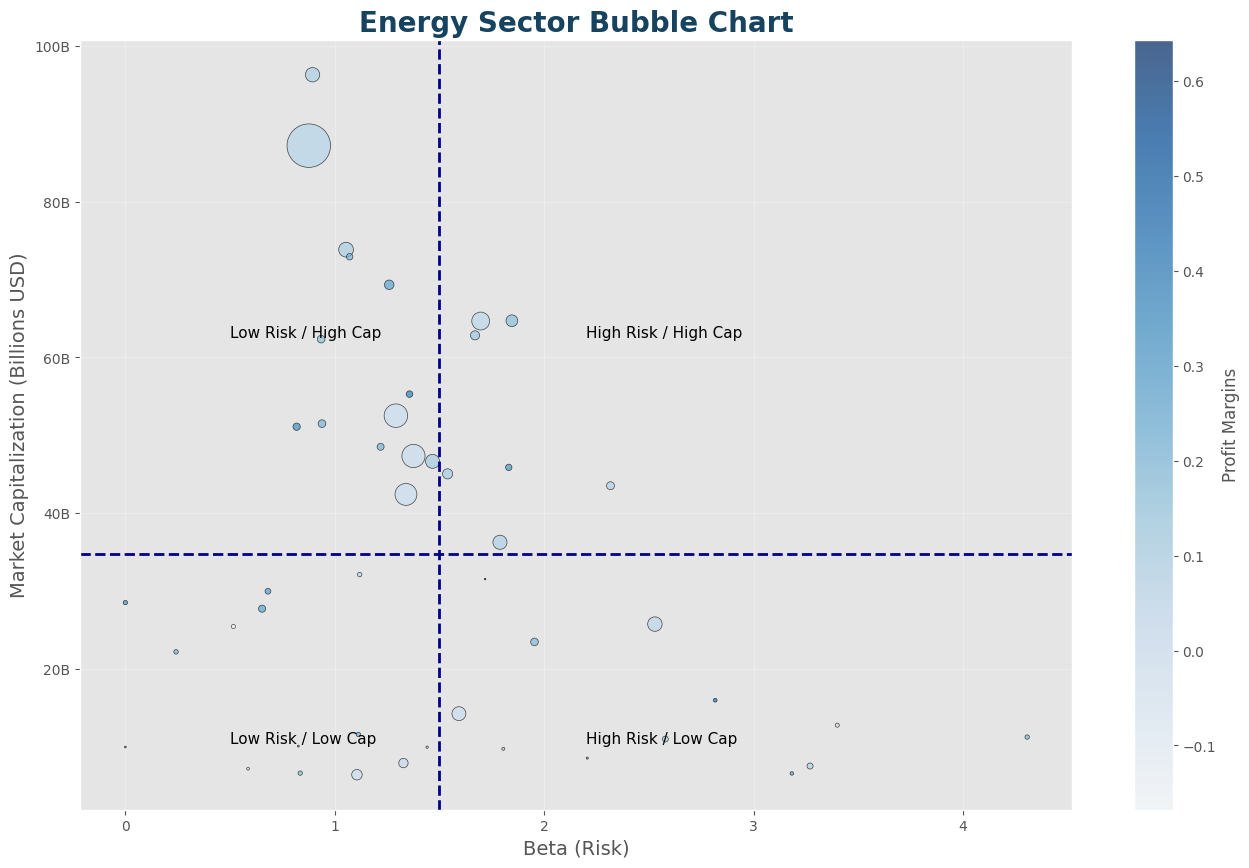

In [128]:
# ============================================================
# Step 6 — Bubble Chart Analysis
# ============================================================

# The bubble chart combines risk, company size,
# profitability, and revenue generation into a
# single financial visualization.

# Create figure
plt.figure(figsize=(16,10))

# Bubble chart
scatter = plt.scatter(
    focus_df['beta'],
    focus_df['market_cap'],
    s=focus_df['total_revenue'] / 5e8,
    c=focus_df['profit_margins'],
    cmap='Blues',
    alpha=0.7,
    edgecolors='black'
)

# Mean values for quadrant separation
x_mean = focus_df['beta'].mean()
y_mean = focus_df['market_cap'].mean()

# Quadrant lines
plt.axvline(
    x=x_mean,
    color='darkblue',
    linestyle='--',
    linewidth=2
)

plt.axhline(
    y=y_mean,
    color='darkblue',
    linestyle='--',
    linewidth=2
)

# Quadrant labels
plt.text(0.5, y_mean*1.8, "Low Risk / High Cap", fontsize=11)
plt.text(2.2, y_mean*1.8, "High Risk / High Cap", fontsize=11)
plt.text(0.5, y_mean*0.3, "Low Risk / Low Cap", fontsize=11)
plt.text(2.2, y_mean*0.3, "High Risk / Low Cap", fontsize=11)

# Improve readability
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(billions_formatter)
)

# Title
plt.title(
    "Energy Sector Bubble Chart",
    fontsize=20,
    fontweight='bold',
    color='#154360'
)

# Labels
plt.xlabel(
    "Beta (Risk)",
    fontsize=14
)

plt.ylabel(
    "Market Capitalization (Billions USD)",
    fontsize=14
)

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Profit Margins')

# Grid
plt.grid(alpha=0.3)

plt.show()

## Selected Quadrant

The selected quadrant is the High Risk / High Cap quadrant.

This quadrant was chosen because it contains large companies with higher beta values, meaning they are potentially more sensitive to market volatility and geopolitical tensions.

These companies are particularly relevant for analyzing the impact of the recent tensions in the Strait of Hormuz on the Energy sector.

In [135]:
# ============================================================
# Step 7 — High Risk / High Cap Selection
# ============================================================

# Companies in this quadrant combine:
# - above-average market capitalization
# - above-average beta values

# Select High Risk / High Cap companies
high_risk_high_cap = focus_df[
    (focus_df['beta'] > focus_df['beta'].mean()) &
    (focus_df['market_cap'] > focus_df['market_cap'].mean())
]

# Keep the largest companies by market capitalization
top10_q1 = (
    high_risk_high_cap
    .sort_values(by='market_cap', ascending=False)
    .head(10)
)

# Display number of selected companies
print("Selected companies:", top10_q1.shape[0])

Selected companies: 7


In [146]:
# ============================================================
# Step 8 — Historical Stock Price Download
# ============================================================

# Extract company tickers
symbols = top10_q1['symbol'].tolist()

# Remove problematic ticker if necessary
symbols = [s for s in symbols if s != 'OKE']

# Download the last three months of adjusted closing prices
prices = yf.download(
    symbols,
    period='3mo',
    auto_adjust=True
)['Close']

# Normalize prices to compare performance
normalized_prices = prices / prices.iloc[0]

# Display dataset dimensions
print("Normalized price dataset shape:", normalized_prices.shape)

[*********************100%***********************]  6 of 6 completed

Normalized price dataset shape: (63, 6)


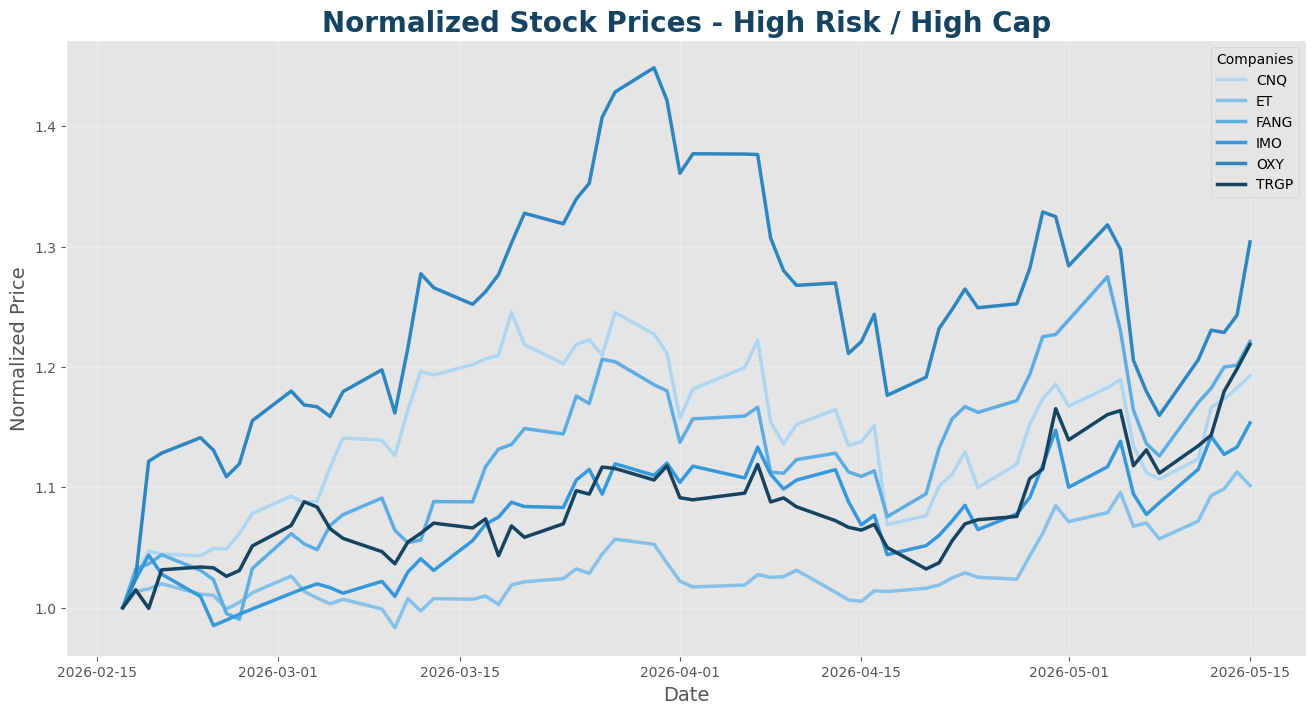

In [151]:
# ============================================================
# Step 9 — Stock Price Performance Analysis
# ============================================================

# The following chart compares the normalized
# stock price performance of the selected companies
# over the last three months.

# Create figure
plt.figure(figsize=(16,8))

# Blue shades palette
colors = ['#AED6F1', '#85C1E9', '#5DADE2',
          '#3498DB', '#2E86C1', '#154360']

# Plot normalized prices
for i, column in enumerate(normalized_prices.columns):

    plt.plot(
        normalized_prices.index,
        normalized_prices[column],
        linewidth=2.5,
        label=column,
        color=colors[i % len(colors)]
    )

# Title
plt.title(
    "Normalized Stock Prices - High Risk / High Cap",
    fontsize=20,
    fontweight='bold',
    color='#154360'
)

# Labels
plt.xlabel(
    "Date",
    fontsize=14
)

plt.ylabel(
    "Normalized Price",
    fontsize=14
)

# Grid
plt.grid(alpha=0.3)

# Legend
plt.legend(
    title='Companies',
    fontsize=10
)

plt.show()

## Price Performance Analysis

The companies in the High Risk / High Cap quadrant showed noticeable volatility during the last three months.

Several firms experienced fluctuations that may reflect the uncertainty linked to the geopolitical tensions in the Strait of Hormuz, an area strategically important for global oil transportation.

Some companies showed temporary declines followed by partial recoveries, suggesting that investors reacted cautiously but did not completely lose confidence in the Energy sector.

Overall, the selected companies appeared moderately affected by the geopolitical environment, with different levels of resilience depending on their market position and operational exposure.

## Comparison Quadrant

The comparison quadrant selected is the Low Risk / Low Cap quadrant.

This group contains companies with lower beta values and smaller market capitalizations, making them potentially less exposed to market volatility and geopolitical shocks.

Comparing this group with the High Risk / High Cap quadrant helps evaluate whether company size and risk profile influenced stock performance during the recent geopolitical tensions.

In [158]:
# ============================================================
# Step 10 — Low Risk / Low Cap Selection
# ============================================================

# Companies in this quadrant combine:
# - below-average market capitalization
# - below-average beta values

# Select Low Risk / Low Cap companies
low_risk_low_cap = focus_df[
    (focus_df['beta'] <= focus_df['beta'].mean()) &
    (focus_df['market_cap'] <= focus_df['market_cap'].mean())
]

# Keep the largest companies by market capitalization
top10_q2 = (
    low_risk_low_cap
    .sort_values(by='market_cap', ascending=False)
    .head(10)
)

# Display number of selected companies
print("Selected companies:", top10_q2.shape[0])

Selected companies: 10


In [161]:
# ============================================================
# Step 11 — Historical Stock Price Download
# ============================================================

# Extract company tickers
symbols2 = top10_q2['symbol'].tolist()

# Download the last three months of adjusted closing prices
prices2 = yf.download(
    symbols2,
    period='3mo',
    auto_adjust=True
)['Close']

# Normalize prices to compare performance
normalized_prices2 = prices2 / prices2.iloc[0]

# Display dataset dimensions
print("Normalized price dataset shape:", normalized_prices2.shape)

[*********************100%***********************]  10 of 10 completed

Normalized price dataset shape: (63, 10)


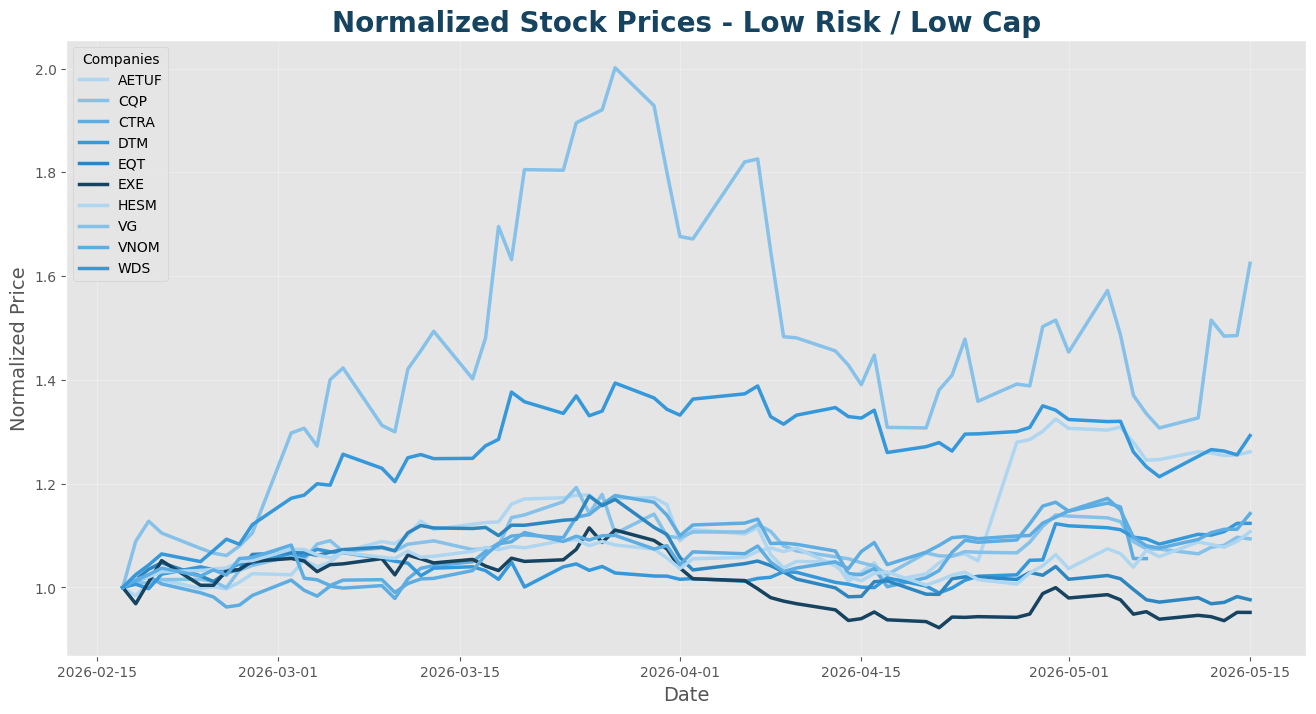

In [163]:
# ============================================================
# Step 12 — Stock Price Performance Analysis
# ============================================================

# The following chart compares the normalized
# stock price performance of the selected
# Low Risk / Low Cap companies.

# Create figure
plt.figure(figsize=(16,8))

# Blue shades palette
colors = ['#AED6F1', '#85C1E9', '#5DADE2',
          '#3498DB', '#2E86C1', '#154360']

# Plot normalized prices
for i, column in enumerate(normalized_prices2.columns):

    plt.plot(
        normalized_prices2.index,
        normalized_prices2[column],
        linewidth=2.5,
        label=column,
        color=colors[i % len(colors)]
    )

# Title
plt.title(
    "Normalized Stock Prices - Low Risk / Low Cap",
    fontsize=20,
    fontweight='bold',
    color='#154360'
)

# Labels
plt.xlabel(
    "Date",
    fontsize=14
)

plt.ylabel(
    "Normalized Price",
    fontsize=14
)

# Grid
plt.grid(alpha=0.3)

# Legend
plt.legend(
    title='Companies',
    fontsize=10
)

plt.show()

## Quadrant Comparison

Compared to the High Risk / High Cap companies, the Low Risk / Low Cap group appeared generally more stable over the observed period.

Price movements were less volatile, suggesting a lower sensitivity to geopolitical tensions and market uncertainty.

The comparison supports the quadrant logic used in the bubble chart: companies with higher beta values and larger market capitalizations tended to experience stronger market reactions, while smaller and less risky firms showed more resilience and stability.

In [165]:
print(df.columns)

Index(['symbol', 'company_name', 'sector', 'industry', 'market_cap',
       'enterprise_value', 'current_price', 'previous_close',
       'fifty_two_week_high', 'fifty_two_week_low', 'fifty_day_average',
       'two_hundred_day_avg', 'beta', 'pe_trailing', 'pe_forward',
       'price_to_sales', 'price_to_book', 'total_revenue', 'net_income',
       'profit_margins', 'free_cashflow', 'debt_to_equity', 'return_on_assets',
       'return_on_equity', 'revenue_growth', 'earnings_growth',
       'last_annual_dividend', 'dividend_yield', 'payout_ratio',
       'average_volume', 'short_ratio', 'exchange', 'exchange_short_name',
       'country', 'is_etf', 'is_fund', 'is_actively_trading', 'timestamp'],
      dtype='str')


# Final Summary

The analysis focused on the Energy sector, after filtering the dataset to include only active companies and removing ETFs and funds.

The sector showed a highly concentrated structure, with a few very large companies dominating market capitalization and revenue distributions. The histogram and boxplot analyses highlighted the presence of strong outliers, particularly among integrated oil and gas companies with extremely large market values.

The industry comparison revealed important differences across Energy industries in terms of profitability, revenue generation, and risk. Oil & Gas Integrated and Oil & Gas Midstream companies displayed the largest market capitalizations and revenues, while Oil & Gas E&P companies showed higher beta values and greater volatility. Oil & Gas Refining & Marketing also presented interesting profitability patterns. For these reasons, these industries were selected for the focus analysis.

The bubble chart provided a useful visualization of the relationship between company size, risk, profitability, and revenue. Using beta on the x-axis and market capitalization on the y-axis allowed the identification of companies with different risk and scale profiles. Bubble size and color helped highlight firms with strong revenues and higher profit margins.

The High Risk / High Cap quadrant contained large companies with elevated beta values, making them particularly relevant for studying the effects of geopolitical uncertainty. The stock price analysis over the last three months showed periods of volatility and temporary declines, likely influenced by tensions in the Strait of Hormuz and concerns about global oil supply disruptions. However, several companies also showed signs of recovery, indicating investor confidence in the long-term strength of the Energy sector.

In contrast, the Low Risk / Low Cap companies showed more stable price behavior and lower volatility. Their reaction to geopolitical tensions appeared more limited, suggesting greater resilience to short-term market shocks.

Overall, the analysis confirmed that the combination of company size and market risk helped explain different market behaviors within the Energy sector during a period of geopolitical uncertainty.